In [1]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
safe_2021 = Path(
    r"../data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE"
)

safe_2026 = Path(
    r"../data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"
)

output_dir = Path("../data/processed")
output_dir.mkdir(exist_ok=True)

In [3]:
def find_band(safe_path, band_name):
    
    img_dir = list(
        safe_path.glob(
            "GRANULE/*/IMG_DATA/R10m"
        )
    )[0]

    matches = list(
        img_dir.glob(f"*_{band_name}_10m.jp2")
    )

    return matches[0]

In [5]:
bands = ["B04", "B08"]

paths_2021 = {}
paths_2026 = {}

for band in bands:
    paths_2021[band] = find_band(
        safe_2021,
        band
    )

    paths_2026[band] = find_band(
        safe_2026,
        band
    )

In [6]:
for b in bands:
    print("\n", b)

    print("2021:", paths_2021[b])
    print("2026:", paths_2026[b])


 B04
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B04_10m.jp2
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B04_10m.jp2

 B08
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B08_10m.jp2
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B08_10m.jp2


In [8]:
def read_band(path):

    with rasterio.open(path) as src:
        return src.read(1)

In [9]:
r21 = read_band(paths_2021["B04"])
nir21 = read_band(paths_2021["B08"])

r26 = read_band(paths_2026["B04"])
nir26 = read_band(paths_2026["B08"])

In [10]:
def ndvi(red, nir):

    return (
        (nir - red)
        /
        (nir + red + 1e-6)
    )

In [11]:
ndvi_2021 = ndvi(
    r21,
    nir21
)

ndvi_2026 = ndvi(
    r26,
    nir26
)

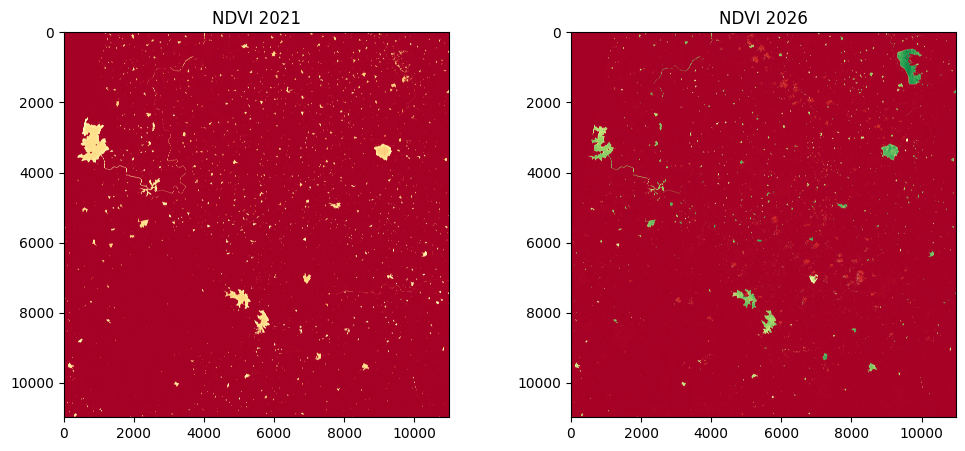

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    ndvi_2021,
    cmap="RdYlGn"
)
plt.title("NDVI 2021")

plt.subplot(1,2,2)
plt.imshow(
    ndvi_2026,
    cmap="RdYlGn"
)
plt.title("NDVI 2026")

plt.show()

In [13]:
ndvi_change = (
    ndvi_2026
    -
    ndvi_2021
)

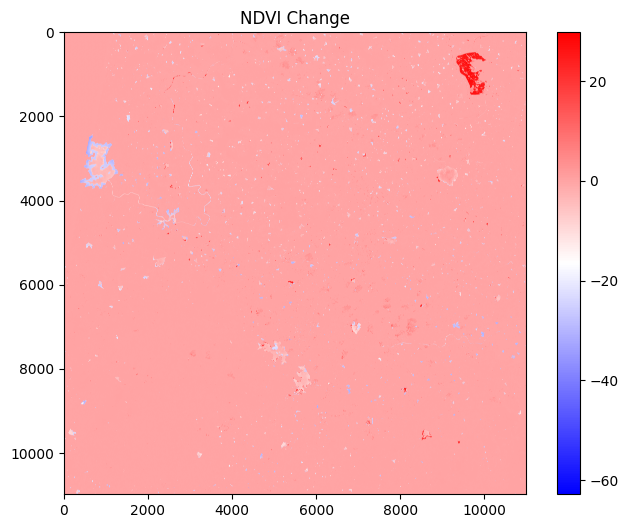

In [14]:
plt.figure(figsize=(8,6))

plt.imshow(
    ndvi_change,
    cmap="bwr"
)

plt.colorbar()

plt.title(
    "NDVI Change"
)

plt.show()

In [15]:
vegetation_loss_mask = (
    ndvi_change < -0.2
).astype(np.uint8)

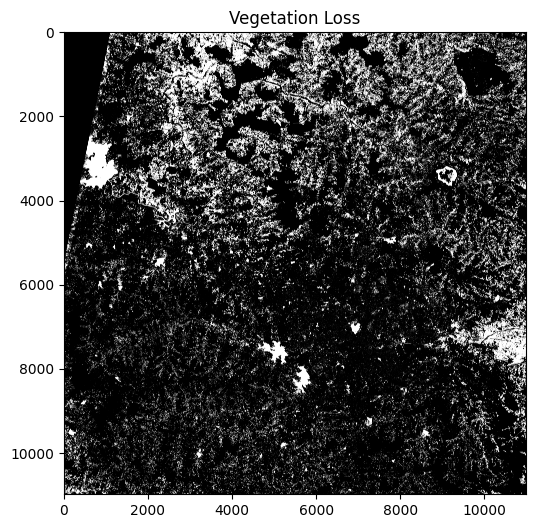

In [16]:
plt.figure(figsize=(8,6))

plt.imshow(
    vegetation_loss_mask,
    cmap="gray"
)

plt.title(
    "Vegetation Loss"
)

plt.show()

In [17]:
ndvi_2021_png = output_dir / "ndvi_2021.png"
ndvi_2026_png = output_dir / "ndvi_2026.png"
ndvi_change_png = output_dir / "ndvi_change.png"
veg_loss_png = output_dir / "vegetation_loss_mask.png"

plt.imsave(ndvi_2021_png, ndvi_2021, cmap="RdYlGn")
plt.imsave(ndvi_2026_png, ndvi_2026, cmap="RdYlGn")
plt.imsave(ndvi_change_png, ndvi_change, cmap="bwr")
plt.imsave(veg_loss_png, vegetation_loss_mask, cmap="gray")